In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
results = pd.read_csv("../data/results.csv")

In [3]:
results = results[
    [
        "driverId",
        "grid",
        "points",
        "positionOrder"
    ]
]

In [4]:
results["winner"] = np.where(
    results["positionOrder"] == 1,
    1,
    0
)

In [5]:
driver_stats = (
    results.groupby("driverId")["points"]
    .mean()
    .reset_index()
)

driver_stats.columns = [
    "driverId",
    "avg_driver_points"
]

In [6]:
ml_data = results.merge(
    driver_stats,
    on="driverId",
    how="left"
)

In [7]:
X = ml_data[
    [
        "grid",
        "points",
        "avg_driver_points"
    ]
]

y = ml_data["winner"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [10]:
future_race = pd.DataFrame({
    "driver": [
        "Verstappen",
        "Norris",
        "Leclerc",
        "Piastri",
        "Russell"
    ],

    "grid": [1, 2, 3, 4, 5],

    "points": [220, 180, 170, 165, 150],

    "avg_driver_points": [15.2, 12.5, 11.8, 11.5, 10.7]
})

In [11]:
X_future = future_race[
    [
        "grid",
        "points",
        "avg_driver_points"
    ]
]

future_race["win_probability"] = (
    rf_model.predict_proba(X_future)[:, 1]
)

In [12]:
future_race = future_race.sort_values(
    by="win_probability",
    ascending=False
)

future_race

,driver,grid,points,avg_driver_points,win_probability
0,Verstappen,1,220,15.2,0.98
1,Norris,2,180,12.5,0.98
4,Russell,5,150,10.7,0.79
2,Leclerc,3,170,11.8,0.75
3,Piastri,4,165,11.5,0.68


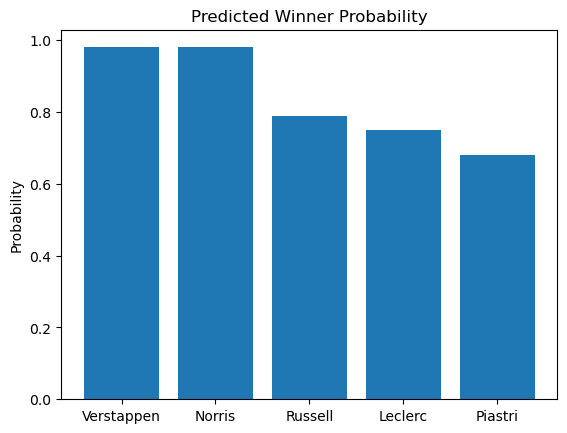

In [13]:
import matplotlib.pyplot as plt

plt.bar(
    future_race["driver"],
    future_race["win_probability"]
)

plt.title("Predicted Winner Probability")
plt.ylabel("Probability")

plt.show()

# Conclusion

The Random Forest model was used to predict race winner probabilities for a hypothetical 2026 Formula 1 race.

Drivers were ranked according to their predicted chance of winning.

This notebook demonstrates how a trained machine learning model can be used for future predictions.